# Object Classification

In [3]:
pip install ultralytics

# All CNN model are written in single cell


0: 480x640 2 persons, 1 dog, 232.1ms
Speed: 7.1ms preprocess, 232.1ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)


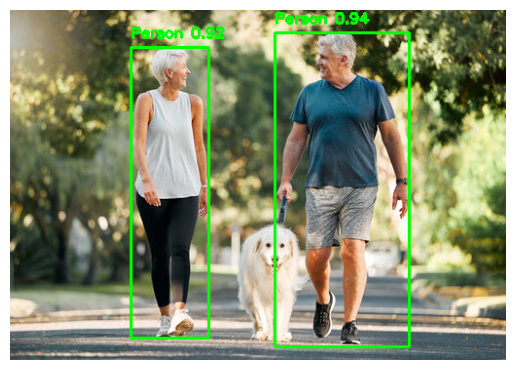

In [6]:
# Import libraries
from ultralytics import YOLO #  YOLO Is used for Image and Video Classification
import cv2 # Cortex Computer Vision
import matplotlib.pyplot as plt # TO plot object boudaries

# Load pre-trained YOLOv8 model
model = YOLO("yolov8n.pt")  # lightweight model

# Load image
image_path = r"/content/humans walking.jpg"   # your JPEG file
image = cv2.imread(image_path)

# Run detection
results = model(image)

# Process results
for result in results:
    boxes = result.boxes

    for box in boxes:
        cls = int(box.cls[0])  # class id
        conf = float(box.conf[0])  # confidence

        # COCO dataset class 0 = person
        if cls == 0:
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw bounding box
            cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)#(0-Red,G-255,0-Red)
            cv2.putText(image, f'Person {conf:.2f}',
                        (x1, y1-10), #  -10 is given to 1st axis becuase Normalization hasto applied
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0,255,0), 2) # 0.5- Denotes  Saturation ofblack-Grey,2-Image is non Black-white

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

# Adding Gender Count As well

In [9]:
pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.5 MB/s eta 0:00:00



0: 448x640 4 persons, 1 cup, 2 chairs, 2 laptops, 1 book, 982.8ms
Speed: 15.8ms preprocess, 982.8ms inference, 3.9ms postprocess per image at shape (1, 3, 448, 640)


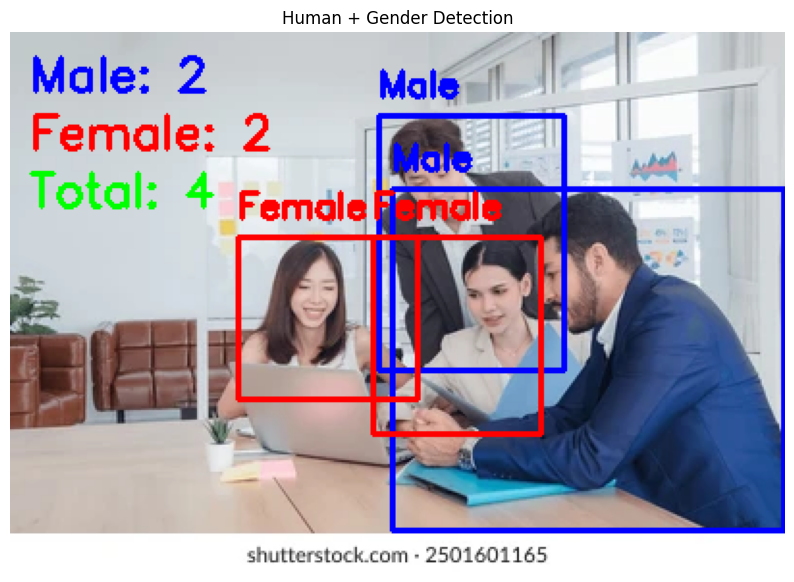

✅ Male Count   : 2
✅ Female Count : 2
✅ Total People : 4


In [11]:
# =========================================
# HUMAN + GENDER DETECTION (REFINED VERSION)
# =========================================

# Install (run once)
# pip install ultralytics opencv-python matplotlib deepface

from ultralytics import YOLO # Image & Video Classification
import cv2 # Computer  Vision
import matplotlib.pyplot as plt # 2D Plots
from deepface import DeepFace # Gender Recognition

# -------------------------------
# LOAD YOLO MODEL
# -------------------------------
model = YOLO("yolov8n.pt")

# -------------------------------
# LOAD IMAGE
# -------------------------------
image_path = r"/content/business-team.webp"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("❌ Image not found. Check path!")

# -------------------------------
# DETECT PERSONS
# -------------------------------
results = model(image)

male_count = 0
female_count = 0

# -------------------------------
# PROCESS EACH PERSON
# -------------------------------
for result in results:
    for box in result.boxes:

        cls = int(box.cls[0])

        # Class 0 = person
        if cls == 0:
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Crop person
            person_img = image[y1:y2, x1:x2]

            if person_img.size == 0:
                continue

            try:
                # -------------------------------
                # GENDER DETECTION (DeepFace)
                # -------------------------------
                analysis = DeepFace.analyze(
                    person_img,
                    actions=['gender'],
                    enforce_detection=False  # if it doesnt see any  image exception is raised
                )

                gender = analysis[0]['dominant_gender']

                # Count + Color
                if gender.lower() == "man":
                    male_count += 1
                    color = (255, 0, 0)
                    label = "Male"
                else:
                    female_count += 1
                    color = (0, 0, 255)
                    label = "Female"

            except Exception as e:
                # If DeepFace fails, skip
                continue

            # -------------------------------
            # DRAW BOX + LABEL
            # -------------------------------
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            cv2.putText(
                image,
                label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

# -------------------------------
# DISPLAY COUNTS
# -------------------------------
total = male_count + female_count

cv2.putText(image, f"Male: {male_count}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

cv2.putText(image, f"Female: {female_count}", (10, 60),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

cv2.putText(image, f"Total: {total}", (10, 90),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# -------------------------------
# SHOW IMAGE
# -------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Human + Gender Detection")
plt.show()

# -------------------------------
# PRINT COUNTS
# -------------------------------
print("✅ Male Count   :", male_count)
print("✅ Female Count :", female_count)
print("✅ Total People :", total)


0: 416x640 1 bird, 1 bear, 165.5ms
Speed: 5.7ms preprocess, 165.5ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)


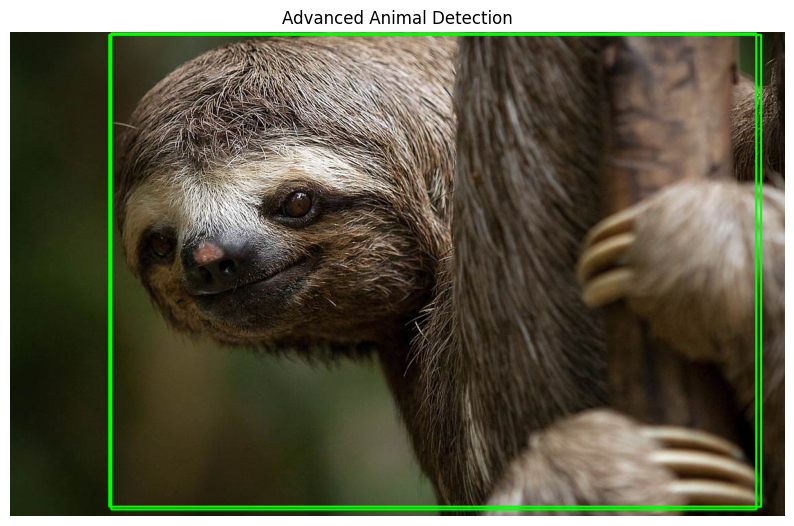


Detected Animals:
three-toed_sloth (0.77)
three-toed_sloth (0.75)


In [13]:
# =========================================
# ADVANCED ANIMAL DETECTION + CLASSIFICATION
# =========================================

# Install (run once)
# pip install ultralytics opencv-python matplotlib tensorflow numpy

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input, decode_predictions

# -------------------------------
# LOAD MODELS
# -------------------------------

# YOLO for detection
yolo_model = YOLO("yolov8n.pt")

# EfficientNet for classification
clf_model = EfficientNetB0(weights="imagenet") # Animals Library

# -------------------------------
# LOAD IMAGE
# -------------------------------
image_path = r"/content/S.jpg"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("❌ Image not found")

# -------------------------------
# DETECT OBJECTS
# -------------------------------
results = yolo_model(image)

detections = []

# -------------------------------
# PROCESS DETECTIONS
# -------------------------------
for result in results:
    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Crop detected region
        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        # -------------------------------
        # CLASSIFICATION (EfficientNet)
        # -------------------------------
        img = cv2.resize(crop, (224, 224))
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)

        preds = clf_model.predict(img, verbose=0)
        decoded = decode_predictions(preds, top=1)[0][0]

        label = decoded[1]   # class name
        confidence = decoded[2]

        # Filter only animals (basic filter)
        if confidence > 0.5:
            detections.append((label, confidence, x1, y1, x2, y2))

# -------------------------------
# DRAW RESULTS
# -------------------------------
for label, conf, x1, y1, x2, y2 in detections:

    cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)

    cv2.putText(
        image,
        f"{label} {conf:.2f}",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,255,0),
        2
    )

# -------------------------------
# SHOW IMAGE
# -------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Advanced Animal Detection")
plt.show()

# -------------------------------
# PRINT RESULTS
# -------------------------------
print("\nDetected Animals:")
for d in detections:
    print(f"{d[0]} ({d[1]:.2f})")